In [21]:
from pathlib import Path
from dataclasses import dataclass
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


from process_ccf import process_ccf_dataset

In [22]:
input_file = "./hpc_results/random_rv_iccf_dataset_soap_spectrum_quiet_step0p1.csv"
output_file = "./CCFs/random_rv_iccf_dataset_soap_spectrum_quiet_step0p1_normalized.parquet"
process_ccf_dataset(input_file, output_file)

Loading hpc_results/random_rv_iccf_dataset_soap_spectrum_quiet_step0p1.csv...
Rounded rv_true_mps to 2 decimals
Normalized CCFs
Rounded CCFs to 4 decimals
Saving to CCFs/random_rv_iccf_dataset_soap_spectrum_quiet_step0p1_normalized.parquet...
Done!


In [23]:
# Load the Parquet file
iccf_0p1_50k = pd.read_parquet(Path(output_file))

# Now you can work with iccf_0p1_50k as usual
iccf_0p1_50k.head()

,rv_true_mps,rv_iccf_mps,fwhm_kms,bis_mps,vspan_mps,wspan_mps,contrast_percent,ccf_0000,ccf_0001,ccf_0002,...,ccf_0291,ccf_0292,ccf_0293,ccf_0294,ccf_0295,ccf_0296,ccf_0297,ccf_0298,ccf_0299,ccf_0300
0,77.40,-146.693695,6.597320,-35.303705,-28.251487,-603.388779,56.713954,0.9788,0.9788,0.9787,...,0.9884,0.9884,0.9883,0.9883,0.9883,0.9882,0.9882,0.9882,0.9882,0.9881
1,43.89,-180.204276,6.597626,-35.453621,-27.440173,-603.794378,56.714368,0.9788,0.9788,0.9787,...,0.9884,0.9883,0.9883,0.9883,0.9882,0.9882,0.9881,0.9882,0.9882,0.9881
2,85.86,-138.228632,6.597244,-35.267085,-28.472872,-603.333098,56.713862,0.9788,0.9788,0.9787,...,0.9884,0.9884,0.9883,0.9883,0.9883,0.9882,0.9882,0.9881,0.9882,0.9881
3,69.74,-154.353225,6.597390,-35.335859,-28.055823,-603.456774,56.714041,0.9788,0.9788,0.9787,...,0.9884,0.9884,0.9883,0.9883,0.9882,0.9882,0.9882,0.9882,0.9882,0.9881
4,9.42,-214.676058,6.597961,-35.210673,-29.142251,-601.875318,56.714733,0.9788,0.9787,0.9787,...,0.9884,0.9883,0.9883,0.9883,0.9882,0.9882,0.9881,0.9882,0.9881,0.9881


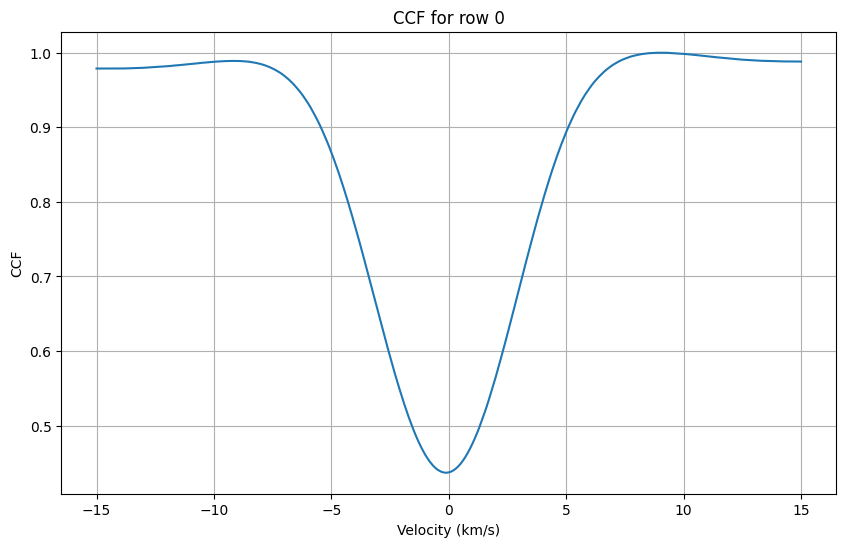

In [24]:
# Plot CCF for a given row
row_index = 0  # Change this to the desired row index
velocities = np.arange(-15, 15.1, 0.1)
ccf_columns = [f'ccf_{i:04d}' for i in range(301)]
ccf_values = iccf_0p1_50k.loc[row_index, ccf_columns].values

plt.figure(figsize=(10, 6))
plt.plot(velocities, ccf_values)
plt.xlabel('Velocity (km/s)')
plt.ylabel('CCF')
plt.title(f'CCF for row {row_index}')
plt.grid(True)
plt.show()